[!] Missing dependencies. Auto-installing now (takes ~1-2 mins)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00
[OK] Installation successful! Proceeding with execution...


[OK] CONFIG ready — device: cpu | batch_size: 512

Loading Ethereum dataset …
Building k-NN behavioural graph (k=10) …
Nodes: 9,841  Edges: 134,238  Fraud rate: 22.1%

Trainable params: 37,537

Building samplers …

 Epoch | Train Loss |   Val Loss | Train F1 |   Val F1 | LR
-----------------------------------------------------------------
     1 |     1.1265 |     0.7046 |   0.9556 |   0.95

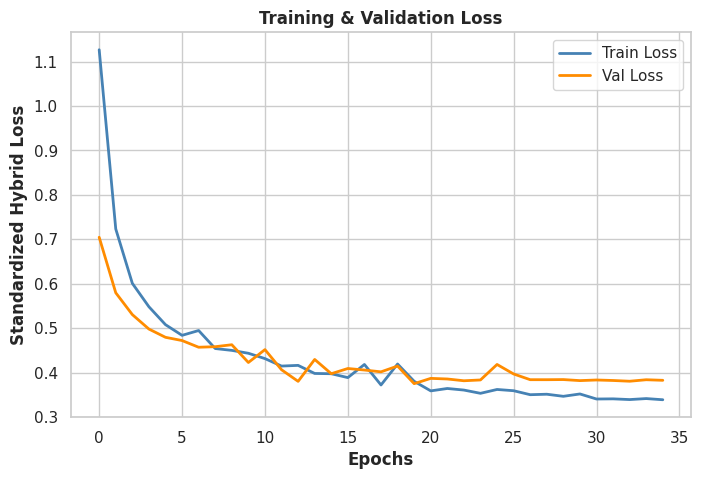

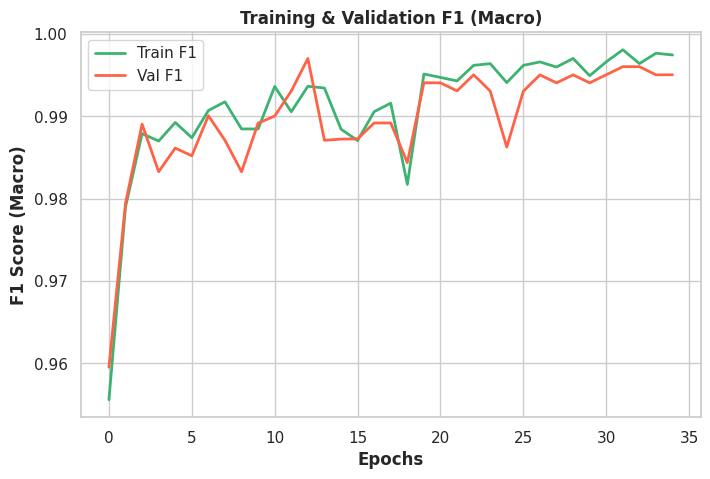

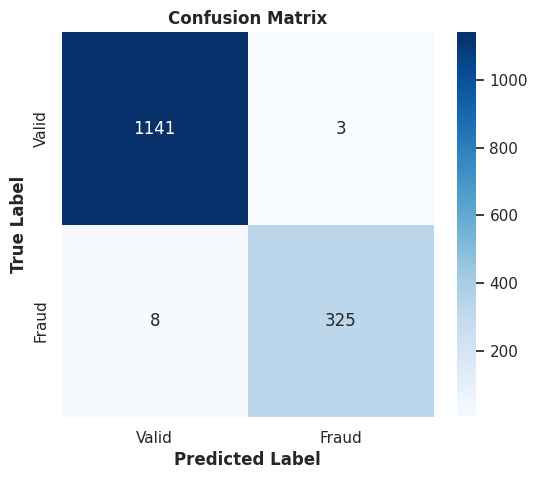


Generating t-SNE visualisation …


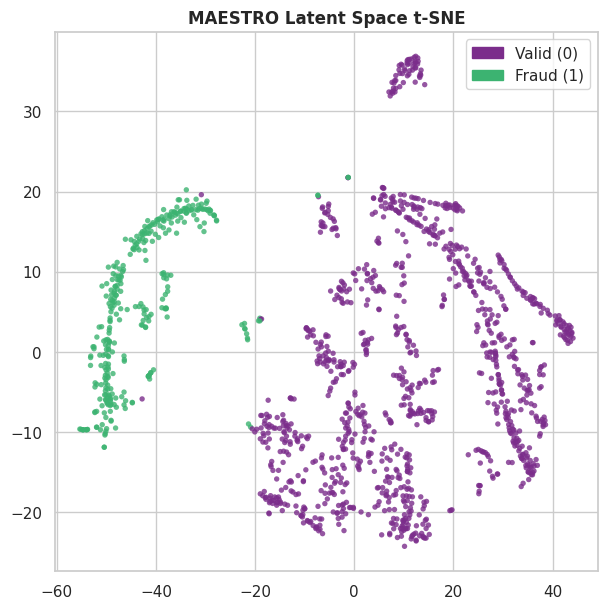


Running XAI (LIME + SHAP) …
  → Generating insights for Node 7663


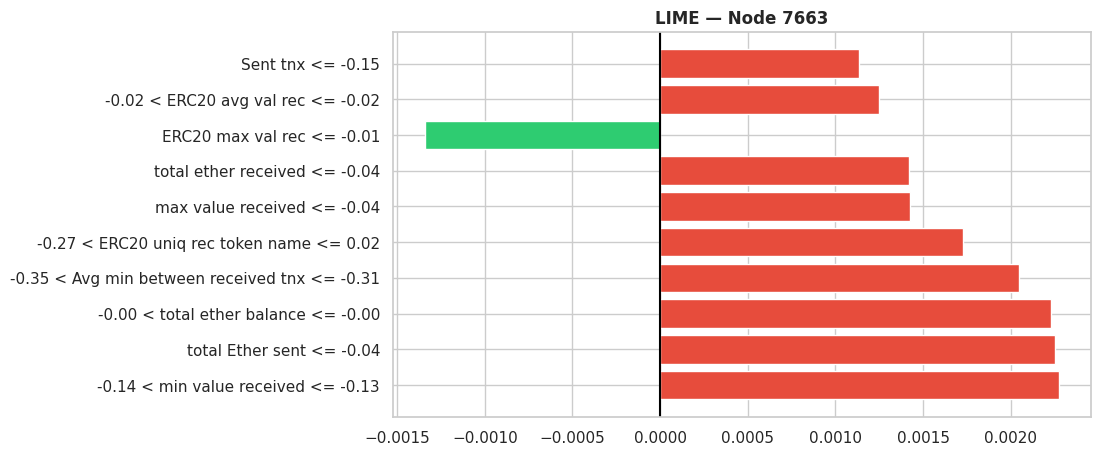

  0%|          | 0/1 [00:00<?, ?it/s]

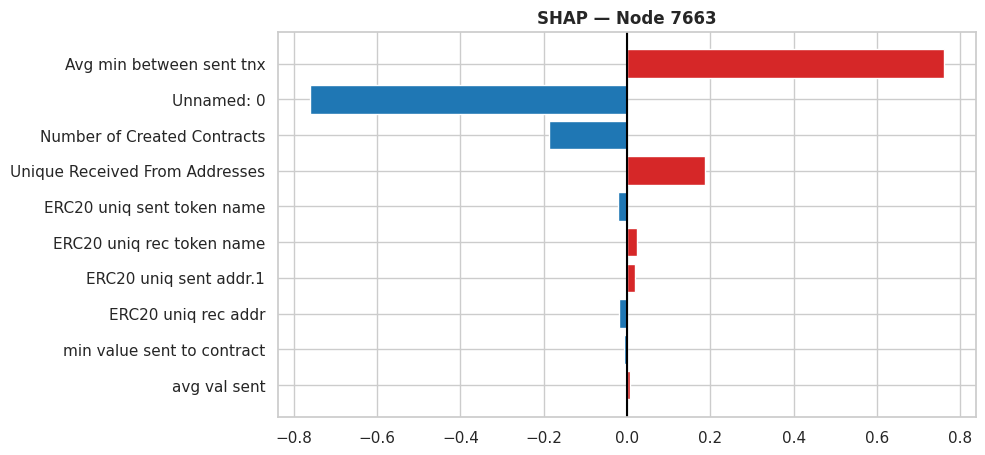

  → Generating insights for Node 7676


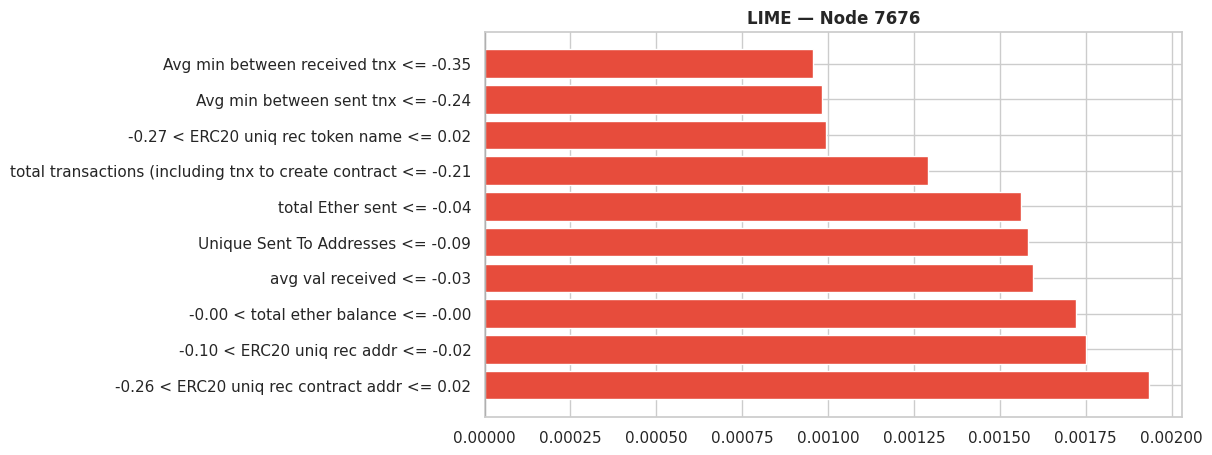

  0%|          | 0/1 [00:00<?, ?it/s]

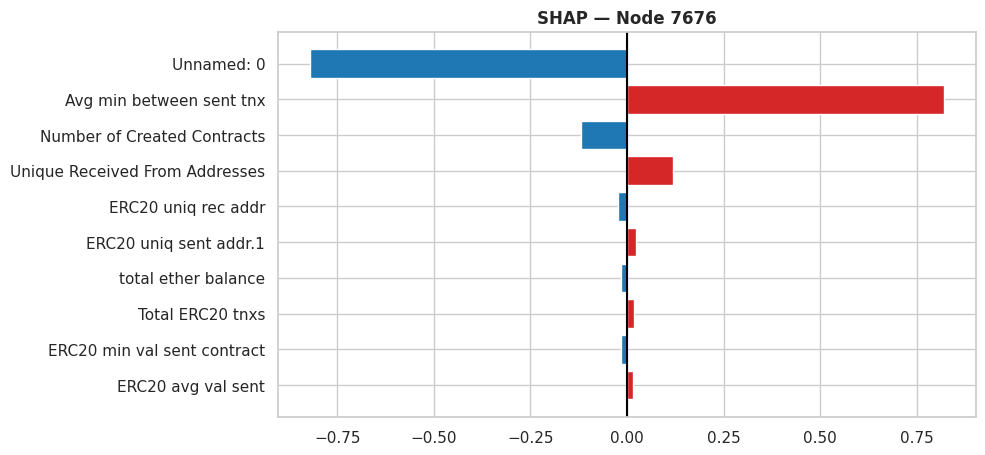


[OK] Pipeline complete. All outputs saved in /kaggle/working/


In [1]:
# ==============================================================================
# 0. DYNAMIC AUTO-INSTALLER GUARD (NO KERNEL RESTART REQUIRED)
# ==============================================================================
import sys, subprocess, importlib

def ensure_dependencies():
    """Silently installs PyG and XAI tools if missing, then invalidates caches."""
    try:
        import torch_geometric
        import shap
        import lime
    except ImportError:
        print("[!] Missing dependencies. Auto-installing now (takes ~1-2 mins)...")
        import torch
        tv = torch.__version__.split("+")[0]
        cuda = ("cu" + torch.version.cuda.replace(".", "")
                if torch.cuda.is_available() else "cpu")
        url = f"https://data.pyg.org/whl/torch-{tv}+{cuda}.html"
        
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet",
            "torch-scatter", "torch-sparse", "torch-cluster",
            "torch-spline-conv", "torch-geometric", "-f", url
        ])
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet", "shap", "lime"
        ])
        importlib.invalidate_caches()
        print("[OK] Installation successful! Proceeding with execution...\n")

ensure_dependencies()

# ==============================================================================
# 1. STANDARD IMPORTS
# ==============================================================================
import os, gc, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Sequential, Dropout, LayerNorm

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv, SAGEConv
from torch_geometric.utils import k_hop_subgraph, dropout_edge, to_undirected

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import lime, lime.lime_tabular

warnings.filterwarnings("ignore")


# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
CONFIG = {
    "data_path": "/kaggle/input/datasets/vagifa/ethereum-frauddetection-dataset/transaction_dataset.csv",
    "save_dir":  "/kaggle/working/",

    "in_channels":     None,
    "hidden_channels": 32,
    "out_channels":    1,
    "attention_heads": 4,
    "dropout_rate":    0.5,

    "knn_k": 10,

    "epochs":              50,
    "learning_rate":       0.001,
    "weight_decay":        1e-2,
    "early_stop_patience": 15,

    "lambda_supcon":   0.05,
    "supcon_temp":     0.1,

    "drop_edge_p":     0.1,
    "batch_size":      512,
    "num_hops":        2,

    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
os.makedirs(CONFIG["save_dir"], exist_ok=True)
print(f"\n[OK] CONFIG ready — device: {CONFIG['device']} | batch_size: {CONFIG['batch_size']}")


# ==============================================================================
# 3. DATA LOADING & STRICT TRANSDUCTIVE SPLITTING
# ==============================================================================
def load_ethereum_data(config):
    print("\nLoading Ethereum dataset …")
    df = pd.read_csv(config["data_path"])
    df.columns = df.columns.str.strip()

    drop_cols   = ["Index", "Address", "ERC20 most sent token type", "ERC20_most_rec_token_type"]
    actual_drop = [c for c in drop_cols if c in df.columns]

    y_raw = df["FLAG"].values
    X_df  = df.drop(columns=actual_drop + ["FLAG"]).apply(pd.to_numeric, errors="coerce")
    feature_names = X_df.columns.tolist()

    n = len(X_df)
    rng = np.random.default_rng(42)
    idx = rng.permutation(n)
    t_end, v_end = int(0.70 * n), int(0.85 * n)

    train_m, val_m, test_m = (torch.zeros(n, dtype=torch.bool) for _ in range(3))
    train_m[idx[:t_end]]    = True
    val_m[idx[t_end:v_end]] = True
    test_m[idx[v_end:]]     = True

    # STRICT TRANSDUCTIVE LEAKAGE FIX
    X_raw = X_df.values
    imputer = SimpleImputer(strategy="median")
    X_raw[train_m] = imputer.fit_transform(X_raw[train_m])
    X_raw[val_m]   = imputer.transform(X_raw[val_m])
    X_raw[test_m]  = imputer.transform(X_raw[test_m])

    scaler = StandardScaler()
    X_scaled = np.empty_like(X_raw)
    X_scaled[train_m] = scaler.fit_transform(X_raw[train_m])
    X_scaled[val_m]   = scaler.transform(X_raw[val_m])
    X_scaled[test_m]  = scaler.transform(X_raw[test_m])

    print(f"Building k-NN behavioural graph (k={config['knn_k']}) …")
    A   = kneighbors_graph(X_scaled, config["knn_k"], mode="connectivity", include_self=False, n_jobs=-1)
    coo = A.tocoo()
    ei  = to_undirected(torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long))

    x = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(y_raw,    dtype=torch.long)

    data = Data(x=x, edge_index=ei, y=y, train_mask=train_m, val_mask=val_m, test_mask=test_m)
    config["in_channels"] = x.shape[1]

    fr = float(y.float().mean())
    print(f"Nodes: {n:,}  Edges: {ei.shape[1]:,}  Fraud rate: {fr*100:.1f}%\n")
    return data, feature_names, fr


# ==============================================================================
# 4. MINI-BATCH SUBGRAPH SAMPLER
# ==============================================================================
class SubgraphBatchSampler:
    def __init__(self, node_indices, batch_size, num_hops, edge_index, num_nodes, shuffle=True):
        self.node_indices = node_indices
        self.batch_size   = batch_size
        self.num_hops     = num_hops
        self.edge_index   = edge_index
        self.num_nodes    = num_nodes
        self.shuffle      = shuffle

    def __iter__(self):
        idx = self.node_indices.clone()
        if self.shuffle:
            idx = idx[torch.randperm(len(idx))]
        for s in range(0, len(idx), self.batch_size):
            seeds = idx[s: s + self.batch_size]
            subset, sub_ei, mapping, _ = k_hop_subgraph(
                node_idx=seeds, num_hops=self.num_hops,
                edge_index=self.edge_index, relabel_nodes=True,
                num_nodes=self.num_nodes, flow="source_to_target",
            )
            yield subset, sub_ei, mapping

    def __len__(self):
        return (len(self.node_indices) + self.batch_size - 1) // self.batch_size


# ==============================================================================
# 5. LOSS FUNCTIONS
# ==============================================================================
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # labels must be integer class indices
        features = F.normalize(features, p=2, dim=1)
        sim      = torch.matmul(features, features.T) / self.temperature
        labels   = labels.contiguous().view(-1, 1)
        mask     = torch.eq(labels, labels.T).float().to(features.device)
        mask.fill_diagonal_(0)
        
        lm, _  = torch.max(sim, dim=1, keepdim=True)
        logits = sim - lm.detach()
        eye    = torch.eye(features.shape[0], device=features.device)
        exp_s  = torch.exp(logits) * (1 - eye)
        log_p  = logits - torch.log(exp_s.sum(1, keepdim=True) + 1e-8)
        
        mask_sum = mask.sum(1)
        loss = -(mask * log_p).sum(1) / (mask_sum + 1e-8)
        return loss.mean()


# ==============================================================================
# 6. MAESTRO ARCHITECTURE
# ==============================================================================
class TransformerFeatureRefiner(nn.Module):
    def __init__(self, in_dim, embed_dim, heads=4):
        super().__init__()
        self.proj  = Linear(in_dim, embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
        self.norm1 = LayerNorm(embed_dim)
        self.norm2 = LayerNorm(embed_dim)
        self.ffn   = Sequential(Linear(embed_dim, embed_dim * 2), nn.GELU(), Linear(embed_dim * 2, embed_dim))

    def forward(self, x):
        h = self.proj(x).unsqueeze(1)
        a, _ = self.attn(h, h, h)
        h    = self.norm1(h + a)
        return self.norm2(h + self.ffn(h)).squeeze(1)


class LocalGlobalGraphLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads, dropout):
        super().__init__()
        self.local_conv  = SAGEConv(in_dim, out_dim)
        self.global_conv = TransformerConv(in_dim, out_dim // heads, heads=heads, dropout=dropout)
        self.fusion = Linear(out_dim * 2, out_dim)
        self.norm   = LayerNorm(out_dim)
        self.drop   = Dropout(dropout)

    def forward(self, x, edge_index):
        h_l = F.gelu(self.local_conv(x, edge_index))
        h_g = F.gelu(self.global_conv(x, edge_index))
        return self.drop(self.norm(self.fusion(torch.cat([h_l, h_g], dim=-1))))


class AdaptiveGatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = Sequential(Linear(dim * 2, dim), nn.Sigmoid())

    def forward(self, a, b):
        g = self.gate(torch.cat([a, b], dim=-1))
        return g * a + (1 - g) * b


class MAESTRO(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads, dropout_rate):
        super().__init__()
        h = hidden_channels
        self.feature_refiner = TransformerFeatureRefiner(in_channels, h, heads)
        self.layer1          = LocalGlobalGraphLayer(h, h, heads, dropout_rate)
        self.layer2          = LocalGlobalGraphLayer(h, h, heads, dropout_rate)
        self.adaptive_fusion = AdaptiveGatedFusion(h)
        self.classifier = Sequential(
            Linear(h * 3, h * 2), LayerNorm(h * 2), nn.GELU(), Dropout(dropout_rate),
            Linear(h * 2, h),     LayerNorm(h),     nn.GELU(), Dropout(dropout_rate),
            Linear(h, out_channels),
        )

    def _encode(self, x, edge_index):
        xr = self.feature_refiner(x)
        h1 = self.layer1(xr, edge_index)
        h2 = self.layer2(h1, edge_index)
        xf = self.adaptive_fusion(xr, h1 + h2)
        return torch.cat([xf, h1, h2], dim=1)

    def forward(self, x, edge_index, drop_edge_p=0.0, return_embs=False):
        if drop_edge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=drop_edge_p, training=True)
        embs   = self._encode(x, edge_index)
        logits = self.classifier(embs)
        return (logits, embs) if return_embs else logits

    @torch.no_grad()
    def get_embeddings(self, x, edge_index):
        return self._encode(x, edge_index)


# ==============================================================================
# 7. TRAINING & EVALUATION (FIXED)
# ==============================================================================
def train_epoch(model, sampler, data, crit, scrit, opt, config):
    """One training epoch – returns average loss over all batches."""
    model.train()
    total_loss, num_nodes = 0.0, 0
    for subset, sub_ei, mapping in sampler:
        sx = data.x[subset].to(config["device"])
        sy = data.y[subset].to(config["device"])
        sei = sub_ei.to(config["device"])

        opt.zero_grad()
        logits, embs = model(sx, sei, drop_edge_p=config["drop_edge_p"], return_embs=True)
        logits = logits.squeeze(-1)

        seed_logits = logits[mapping]
        seed_labels_float = sy[mapping].float()          # for BCE
        seed_labels_long  = sy[mapping]                  # for contrastive

        bce_loss = crit(seed_logits, seed_labels_float)
        con_loss = scrit(embs[mapping], seed_labels_long)
        loss = bce_loss + config["lambda_supcon"] * con_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_loss += loss.item() * len(seed_labels_float)
        num_nodes += len(seed_labels_float)

    return total_loss / max(num_nodes, 1)

@torch.no_grad()
def evaluate_epoch(model, sampler, data, crit, scrit, config):
    """Validation/test epoch – returns (avg_loss, macro_f1, labels, preds, probs)."""
    model.eval()
    total_loss, total_nodes = 0.0, 0
    all_logits, all_labels = [], []

    for subset, sub_ei, mapping in sampler:
        sx = data.x[subset].to(config["device"])
        sy = data.y[subset].to(config["device"])
        sei = sub_ei.to(config["device"])

        logits, embs = model(sx, sei, drop_edge_p=0.0, return_embs=True)
        logits = logits.squeeze(-1)

        seed_logits = logits[mapping]
        seed_labels_float = sy[mapping].float()
        seed_labels_long  = sy[mapping]

        bce_loss = crit(seed_logits, seed_labels_float)
        con_loss = scrit(embs[mapping], seed_labels_long)
        loss = bce_loss + config["lambda_supcon"] * con_loss

        total_loss += loss.item() * len(seed_labels_float)
        total_nodes += len(seed_labels_float)

        all_logits.append(seed_logits.cpu())
        all_labels.append(seed_labels_long.cpu())      # store long for metrics

    avg_loss = total_loss / max(total_nodes, 1)
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(logits).numpy()
    preds  = (probs > 0.5).astype(int)
    f1     = f1_score(labels, preds, average="macro", zero_division=0)

    return avg_loss, f1, labels, preds, probs

def train_model(model, data, config, fraud_rate):
    print("\nBuilding samplers …")
    train_idx = torch.where(data.train_mask)[0]
    val_idx   = torch.where(data.val_mask)[0]

    train_sampler = SubgraphBatchSampler(
        train_idx, config["batch_size"], config["num_hops"],
        data.edge_index, data.num_nodes, shuffle=True
    )
    val_sampler = SubgraphBatchSampler(
        val_idx, config["batch_size"] * 2, config["num_hops"],
        data.edge_index, data.num_nodes, shuffle=False
    )

    pos_weight = torch.tensor([(1.0 - fraud_rate) / fraud_rate], dtype=torch.float, device=config["device"])
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    scrit = SupervisedContrastiveLoss(config["supcon_temp"])

    opt = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    # Fix: removed deprecated 'verbose' argument
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5, min_lr=1e-5
    )

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    print("\n" + "=" * 65)
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>8} | {'Val F1':>8} | LR")
    print("-" * 65)

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_epoch(model, train_sampler, data, crit, scrit, opt, config)

        # Quick train F1 on one large batch (for logging)
        dummy_sampler = SubgraphBatchSampler(
            train_idx, config["batch_size"] * 2, config["num_hops"],
            data.edge_index, data.num_nodes, shuffle=False
        )
        _, train_f1, *_ = evaluate_epoch(model, dummy_sampler, data, crit, scrit, config)

        val_loss, val_f1, _, _, _ = evaluate_epoch(model, val_sampler, data, crit, scrit, config)

        scheduler.step(val_loss)
        current_lr = opt.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_f1:>8.4f} | {val_f1:>8.4f} | {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["early_stop_patience"]:
            print(f"\n[!] Early stopping at epoch {epoch} (val loss did not improve for {config['early_stop_patience']} epochs).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[OK] Restored best model (val_loss: {best_val_loss:.4f}).")

    return model, history, crit, scrit


def evaluate_model(model, data, config, crit, scrit):
    test_idx = torch.where(data.test_mask)[0]
    test_sampler = SubgraphBatchSampler(
        test_idx, config["batch_size"] * 2, config["num_hops"],
        data.edge_index, data.num_nodes, shuffle=False
    )
    _, _, y_true, preds, probs = evaluate_epoch(model, test_sampler, data, crit, scrit, config)

    print("\n" + "=" * 65)
    print("FINAL TEST SET EVALUATION — MAESTRO")
    print("=" * 65)
    print(classification_report(y_true, preds, digits=4, target_names=["Valid (0)", "Fraud (1)"]))
    print("-" * 65)
    for name, val in [
        ("Accuracy", accuracy_score(y_true, preds)),
        ("Precision", precision_score(y_true, preds, zero_division=0)),
        ("Recall", recall_score(y_true, preds, zero_division=0)),
        ("F1-Score", f1_score(y_true, preds, zero_division=0)),
        ("ROC-AUC", roc_auc_score(y_true, probs)),
        ("PR-AUC", average_precision_score(y_true, probs)),
        ("MCC", matthews_corrcoef(y_true, preds)),
        ("Cohen's Kappa", cohen_kappa_score(y_true, preds)),
    ]:
        print(f"  {name:<18}: {val:.4f}")

    return y_true, preds, probs


# ==============================================================================
# 8. VISUALISATIONS & XAI
# ==============================================================================
def plot_metrics(history, y_true, preds, probs, config):
    def _s(fname): plt.savefig(os.path.join(config["save_dir"], fname), dpi=150, bbox_inches="tight"); plt.show(); plt.close()
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue", lw=2)
    ax.plot(history["val_loss"], label="Val Loss", color="darkorange", lw=2)
    ax.set_title("Training & Validation Loss", weight="bold")
    ax.set_xlabel("Epochs", weight="bold"); ax.set_ylabel("Standardized Hybrid Loss", weight="bold")
    ax.legend(); _s("plot1_loss_curve.png")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["train_f1"], label="Train F1", color="mediumseagreen", lw=2)
    ax.plot(history["val_f1"], label="Val F1", color="tomato", lw=2)
    ax.set_title("Training & Validation F1 (Macro)", weight="bold")
    ax.set_xlabel("Epochs", weight="bold"); ax.set_ylabel("F1 Score (Macro)", weight="bold")
    ax.legend(); _s("plot2_f1_curve.png")

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("Confusion Matrix", weight="bold")
    ax.set_xlabel("Predicted Label", weight="bold"); ax.set_ylabel("True Label", weight="bold")
    ax.set_xticklabels(["Valid", "Fraud"]); ax.set_yticklabels(["Valid", "Fraud"])
    _s("plot3_confusion_matrix.png")

def plot_tsne(model, data, config, n_samples=3000):
    print("\nGenerating t-SNE visualisation …")
    model.eval()
    test_idx  = torch.where(data.test_mask)[0]
    n_samples = min(n_samples, len(test_idx))
    chosen    = test_idx[torch.randperm(len(test_idx))[:n_samples]]

    all_embs, all_labels = [], []
    for s in range(0, len(chosen), 128):
        seeds = chosen[s: s + 128]
        sub, sei, mp, _ = k_hop_subgraph(seeds, config["num_hops"], data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes, flow="source_to_target")
        e = model.get_embeddings(data.x[sub].to(config["device"]), sei.to(config["device"]))
        all_embs.append(e[mp].cpu()); all_labels.append(data.y[seeds])

    coords = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(torch.cat(all_embs).numpy())
    colors = ["#7B2D8B" if l == 0 else "#3CB371" for l in torch.cat(all_labels).numpy()]
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=15, alpha=0.8, linewidths=0)
    handles = [mpatches.Patch(color="#7B2D8B", label="Valid (0)"), mpatches.Patch(color="#3CB371", label="Fraud (1)")]
    ax.legend(handles=handles); ax.set_title("MAESTRO Latent Space t-SNE", weight="bold")
    plt.savefig(os.path.join(config["save_dir"], "plot6_tsne.png"), dpi=150, bbox_inches="tight"); plt.show(); plt.close()

def _xai_wrapper(model, data, node_id, device, num_hops):
    sub, sei, mp, _ = k_hop_subgraph(torch.tensor([node_id]), num_hops, data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes)
    pos, sei_d, base_x = mp[0].item(), sei.to(device), data.x[sub].clone()

    def fn(arr):
        out = []
        for feat in arr:
            tx = base_x.clone()
            tx[pos] = torch.tensor(feat, dtype=torch.float)
            with torch.no_grad():
                lg = model(tx.to(device), sei_d).squeeze(-1)
                p  = torch.sigmoid(lg[pos] if lg.dim() > 0 else lg).item()
            out.append([1 - p, p])
        return np.array(out)
    return fn

def explain_predictions(model, data, feature_names, config, num_examples=2):
    print("\nRunning XAI (LIME + SHAP) …")
    model.eval()
    test_idx = torch.where(data.test_mask)[0]
    with torch.no_grad():
        all_p = (torch.sigmoid(model(data.x.to(config["device"]), data.edge_index.to(config["device"])).squeeze(-1)) > 0.5).cpu().long()

    tp = [i.item() for i in test_idx if data.y[i] == 1 and all_p[i] == 1]
    if not tp: tp = [i.item() for i in test_idx if data.y[i] == 1]

    bg_idx  = torch.where(data.train_mask)[0]
    bg_data = data.x[bg_idx[data.y[bg_idx] == 0][:100]].numpy()

    for i in range(min(num_examples, len(tp))):
        nid  = tp[i]
        feat = data.x[nid].numpy().reshape(1, -1)
        wrap = _xai_wrapper(model, data, nid, config["device"], config["num_hops"])
        print(f"  → Generating insights for Node {nid}")

        ex = lime.lime_tabular.LimeTabularExplainer(bg_data, feature_names=feature_names, class_names=["Valid", "Fraud"], mode="classification")
        exp = ex.explain_instance(feat[0], wrap, num_features=10)
        fig, ax = plt.subplots(figsize=(9, 5))
        ns, ws  = [f[0] for f in exp.as_list(label=1)], [f[1] for f in exp.as_list(label=1)]
        ax.barh(ns, ws, color=["#E74C3C" if w > 0 else "#2ECC71" for w in ws])
        ax.axvline(0, color="black"); ax.set_title(f"LIME — Node {nid}", weight="bold")
        plt.savefig(os.path.join(config["save_dir"], f"xai_lime_{nid}.png"), dpi=150, bbox_inches="tight"); plt.show(); plt.close()

        se  = shap.KernelExplainer(wrap, shap.kmeans(bg_data, 15))
        sv  = se.shap_values(feat, nsamples=50)
        sv = np.asarray(sv[1][0] if isinstance(sv, list) and len(sv) > 1 else sv[0][0] if isinstance(sv, list) else sv).flatten()[:len(feature_names)]
        
        top = np.argsort(np.abs(sv))[::-1][:10]
        tn, tv  = [feature_names[j] for j in top], sv[top]
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(tn[::-1], tv[::-1], color=["#D62728" if v > 0 else "#1F77B4" for v in tv[::-1]])
        ax.axvline(0, color="black"); ax.set_title(f"SHAP — Node {nid}", weight="bold")
        plt.savefig(os.path.join(config["save_dir"], f"xai_shap_{nid}.png"), dpi=150, bbox_inches="tight"); plt.show(); plt.close()


# ==============================================================================
# 9. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    data, feature_names, fr = load_ethereum_data(CONFIG)

    model = MAESTRO(
        in_channels=CONFIG["in_channels"], hidden_channels=CONFIG["hidden_channels"],
        out_channels=CONFIG["out_channels"], heads=CONFIG["attention_heads"],
        dropout_rate=CONFIG["dropout_rate"],
    ).to(CONFIG["device"])
    print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    model, history, crit, scrit = train_model(model, data, CONFIG, fr)
    y_true, preds, probs = evaluate_model(model, data, CONFIG, crit, scrit)
    
    plot_metrics(history, y_true, preds, probs, CONFIG)
    plot_tsne(model, data, CONFIG)
    explain_predictions(model, data, feature_names, CONFIG, num_examples=2)
    
    print(f"\n[OK] Pipeline complete. All outputs saved in {CONFIG['save_dir']}")